<a href="https://colab.research.google.com/github/OSVHdez0/Desarrollo-Gu-a-2-PCD/blob/main/Analisis_Reclamos_Salud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Reclamos en Salud - Semestre 1 2025
### Filtro: Bucaramanga | Clasificación de riesgo con Machine Learning

## 1. Importación de librerías e instalación de dependencias

In [20]:
# Instalación de librería para manejo de archivos Excel
!pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset

In [21]:
# Lectura del archivo CSV con separador punto y coma y codificación latin-1
dataset = pd.read_csv(
    '/content/Reclamos_en_salud_semestre_1_2025_CSV.csv',
    sep=';',
    encoding='latin-1'
)

print('Primeras filas:')
print(dataset.head())
print('\nDimensiones del dataset:', dataset.shape)

Primeras filas:
   ï»¿OBJECTID  periodo  mes      pqr_canal  pet_cod_depto  pet_cod_mpio  \
0            1     2025    1  Personalizado           44.0       44430.0   
1            2     2025    1  Personalizado           44.0       44430.0   
2            3     2025    1  Personalizado           44.0       44430.0   
3            4     2025    6        Escrito           50.0       50001.0   
4            5     2025    6            Web           11.0       11001.0   

           id_afec  afec_parentesco afec_genero  afec_edad  ...  \
0  US-000004528688  A nombre propio      HOMBRE         42  ...   
1  US-000004528689  A nombre propio       MUJER         19  ...   
2  US-000004528689  A nombre propio       MUJER         19  ...   
3  US-000004528691             Otro       MUJER         27  ...   
4  US-000004528692            Madre       MUJER          0  ...   

                                   motivo_especifico cod_tipo_motesp  \
0  FALTA DE OPORTUNIDAD EN EL PROCESO DE REFERENC...

## 3. Filtrado y selección de datos

In [22]:
# Verificar nombres de columnas disponibles
print('Columnas del dataset:')
print(dataset.columns.tolist())

# Filtrar registros correspondientes al municipio de Bucaramanga (código 68001)
dataset_bga = dataset[dataset['pet_cod_mpio'] == 68001]
print('\nRegistros de Bucaramanga:', dataset_bga.shape)

Columnas del dataset:
['ï»¿OBJECTID', 'periodo', 'mes', 'pqr_canal', 'pet_cod_depto', 'pet_cod_mpio', 'id_afec', 'afec_parentesco', 'afec_genero', 'afec_edad', 'afec_edadr', 'afec_educ', 'afec_regafiliacion', 'afec_getnico', 'afec_pobespecial', 'afec_cod_depto', 'afec_cod_mpio', 'ent_nombre', 'ent_tipovig_sns', 'ent_cod_sns', 'ent_alias_sn', 'ent_cod_depto', 'ent_cod_mpio', 'cod_macromot', 'macromotivo', 'cod_motgen', 'motivo_general', 'cod_motesp', 'motivo_especifico', 'cod_tipo_motesp', 'tipo_de_motivo_especifico', 'cod_subtipo_motesp', 'subtipo_de_motivo_especifico', 'patologia_1', 'patologia_tipo', 'cie_10', 'alto_costo', 'clasificacion_de_riesgo']

Registros de Bucaramanga: (426, 38)


In [23]:
# Seleccionar únicamente las columnas relevantes para el análisis
columnas_utiles = [
    'mes',
    'pqr_canal',
    'afec_genero',
    'afec_edad',
    'afec_edadr',
    'afec_regafiliacion',
    'ent_nombre',
    'macromotivo',
    'motivo_general',
    'motivo_especifico',
    'clasificacion_de_riesgo'
]

dataset_bga = dataset_bga[columnas_utiles]
print('Primeras filas del dataset filtrado:')
print(dataset_bga.head())

Primeras filas del dataset filtrado:
      mes      pqr_canal afec_genero  afec_edad        afec_edadr  \
570     6  Personalizado       MUJER         28  DE 25 A 29 AÃOS   
571     4  Personalizado       MUJER         28  DE 25 A 29 AÃOS   
793     4            Web      HOMBRE         21  DE 18 A 24 AÃOS   
1630    1  Personalizado      HOMBRE         22  DE 18 A 24 AÃOS   
2837    5            Web       MUJER         23  DE 18 A 24 AÃOS   

     afec_regafiliacion ent_nombre  \
570          Subsidiado  NUEVA EPS   
571          Subsidiado  NUEVA EPS   
793        Contributivo  NUEVA EPS   
1630       Contributivo  FAMISANAR   
2837         Subsidiado  NUEVA EPS   

                                            macromotivo  \
570   BARRERAS EN EL ACCESO A TECNOLOGÃAS Y SERVICI...   
571   BARRERAS EN EL ACCESO A TECNOLOGÃAS Y SERVICI...   
793   BARRERAS EN EL ACCESO A TECNOLOGÃAS Y SERVICI...   
1630  BARRERAS EN EL ACCESO A TECNOLOGÃAS Y SERVICI...   
2837  BARRERAS EN EL ACC

## 4. Limpieza de datos

In [24]:
# Revisar cantidad de valores nulos por columna
print('Valores nulos por columna:')
print(dataset_bga.isnull().sum())

# Eliminar filas con valores nulos y registros duplicados
dataset_bga = dataset_bga.dropna()
dataset_bga = dataset_bga.drop_duplicates()

print('\nDimensiones después de la limpieza:', dataset_bga.shape)

Valores nulos por columna:
mes                        0
pqr_canal                  0
afec_genero                0
afec_edad                  0
afec_edadr                 0
afec_regafiliacion         0
ent_nombre                 0
macromotivo                0
motivo_general             0
motivo_especifico          0
clasificacion_de_riesgo    0
dtype: int64

Dimensiones después de la limpieza: (420, 11)


## 5. Análisis exploratorio de datos (EDA)

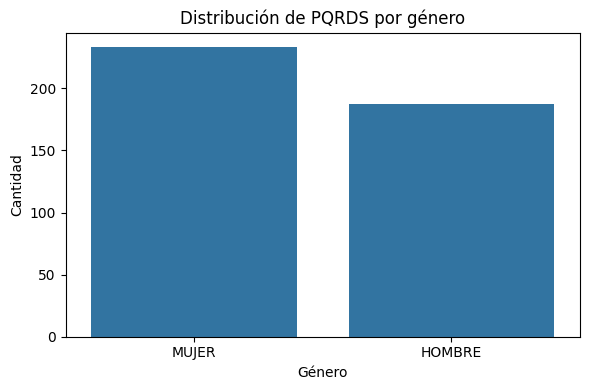

In [25]:
# Distribución de PQRDS según el género del afectado
plt.figure(figsize=(6, 4))
sns.countplot(data=dataset_bga, x='afec_genero')
plt.title('Distribución de PQRDS por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

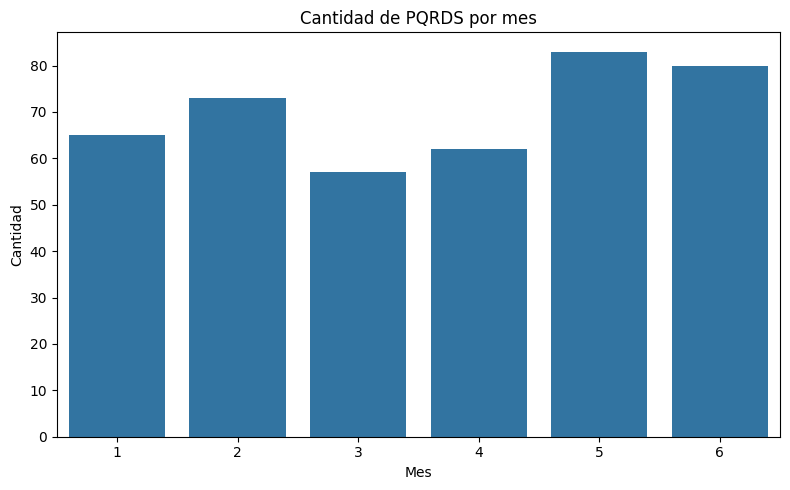

In [26]:
# Distribución de PQRDS por mes del año
plt.figure(figsize=(8, 5))
sns.countplot(data=dataset_bga, x='mes')
plt.title('Cantidad de PQRDS por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

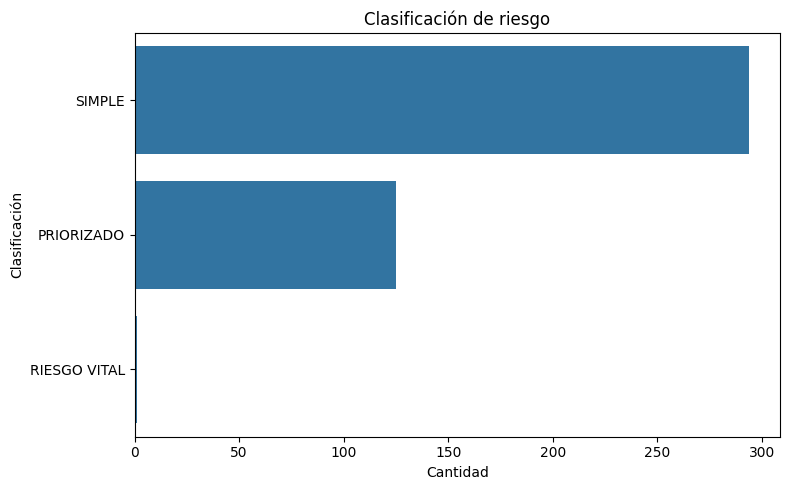

In [27]:
# Clasificación de riesgo: frecuencia de cada categoría ordenada de mayor a menor
plt.figure(figsize=(8, 5))
sns.countplot(
    data=dataset_bga,
    y='clasificacion_de_riesgo',
    order=dataset_bga['clasificacion_de_riesgo'].value_counts().index
)
plt.title('Clasificación de riesgo')
plt.xlabel('Cantidad')
plt.ylabel('Clasificación')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6295/1495313189.py:11: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6295/1495313189.py:11: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6295/1495313189.py:11: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6295/1495313189.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: 

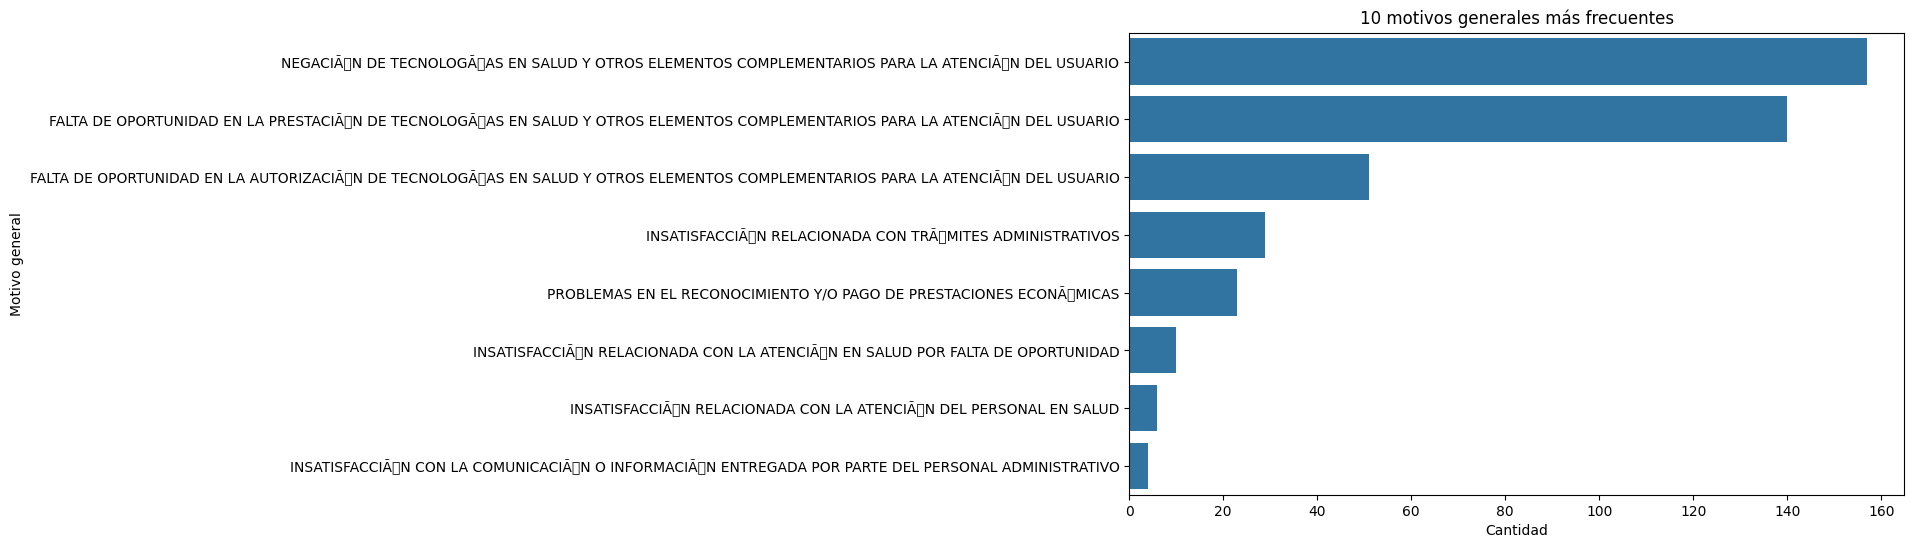

In [28]:
# Top 10 motivos generales con mayor cantidad de PQRDS
plt.figure(figsize=(10, 6))
sns.countplot(
    data=dataset_bga,
    y='motivo_general',
    order=dataset_bga['motivo_general'].value_counts().iloc[:10].index
)
plt.title('10 motivos generales más frecuentes')
plt.xlabel('Cantidad')
plt.ylabel('Motivo general')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6295/3950003074.py:8: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


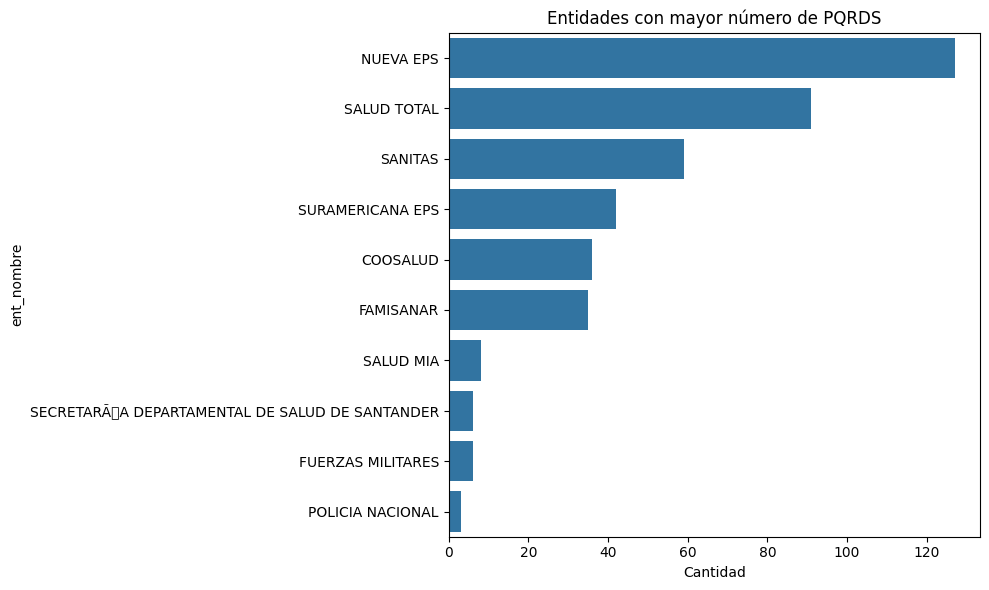

In [29]:
# Entidades con mayor número de PQRDS registradas
top_entidades = dataset_bga['ent_nombre'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_entidades.values, y=top_entidades.index)
plt.title('Entidades con mayor número de PQRDS')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

## 6. Preparación para Machine Learning

In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Codificar variables categóricas (texto) a valores numéricos con LabelEncoder
datos_ml = dataset_bga.copy()
label_encoder = LabelEncoder()

for columna in datos_ml.columns:
    if datos_ml[columna].dtype == 'object':
        datos_ml[columna] = label_encoder.fit_transform(datos_ml[columna])

print('Datos codificados:')
print(datos_ml.head())

Datos codificados:
      mes  pqr_canal  afec_genero  afec_edad  afec_edadr  afec_regafiliacion  \
570     6          3            1         28           1                   3   
571     4          3            1         28           1                   3   
793     4          6            0         21           0                   0   
1630    1          3            0         22           0                   0   
2837    5          6            1         23           0                   3   

      ent_nombre  macromotivo  motivo_general  motivo_especifico  \
570            6            0               6                 21   
571            6            0               1                  7   
793            6            0               1                  8   
1630           3            0               0                  6   
2837           6            0               1                  8   

      clasificacion_de_riesgo  
570                         0  
571                        

In [31]:
# Separar variables predictoras (X) y variable objetivo (y)
X = datos_ml.drop('clasificacion_de_riesgo', axis=1)
y = datos_ml['clasificacion_de_riesgo']

# Dividir en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:', X_test.shape)

Tamaño entrenamiento: (336, 10)
Tamaño prueba: (84, 10)


## 7. Modelos de clasificación

### 7.1 Regresión Logística

Accuracy Regresión Logística: 0.7142857142857143
              precision    recall  f1-score   support

           0       1.00      0.14      0.25        28
           2       0.70      1.00      0.82        56

    accuracy                           0.71        84
   macro avg       0.85      0.57      0.54        84
weighted avg       0.80      0.71      0.63        84



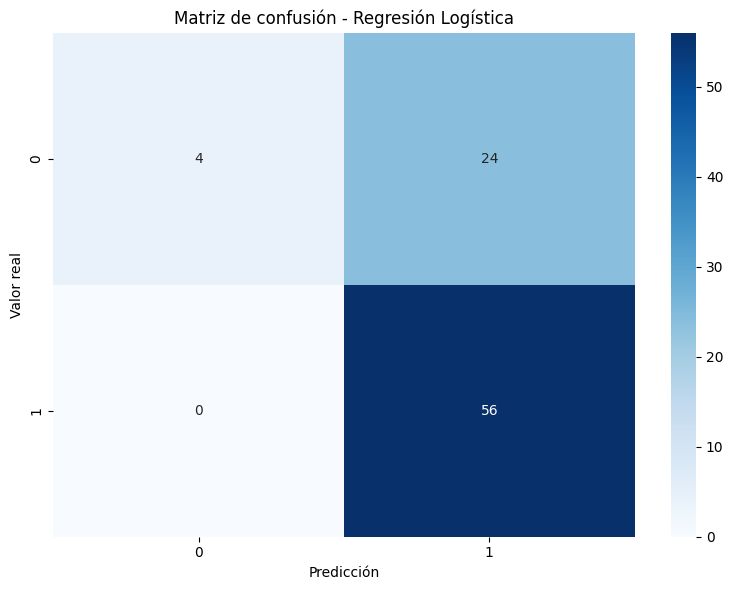

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Entrenar modelo y generar predicciones
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

# Métricas de evaluación
print('Accuracy Regresión Logística:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

### 7.2 Árbol de Decisión

In [33]:
from sklearn.tree import DecisionTreeClassifier

# Entrenar modelo y generar predicciones
modelo_tree = DecisionTreeClassifier(random_state=42)
modelo_tree.fit(X_train, y_train)
y_pred_tree = modelo_tree.predict(X_test)

# Métricas de evaluación
print('Accuracy Árbol de Decisión:', accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy Árbol de Decisión: 0.6428571428571429
              precision    recall  f1-score   support

           0       0.45      0.32      0.38        28
           2       0.70      0.80      0.75        56

    accuracy                           0.64        84
   macro avg       0.58      0.56      0.56        84
weighted avg       0.62      0.64      0.62        84



### 7.3 Random Forest

Accuracy Random Forest: 0.6904761904761905
              precision    recall  f1-score   support

           0       0.58      0.25      0.35        28
           2       0.71      0.91      0.80        56

    accuracy                           0.69        84
   macro avg       0.65      0.58      0.57        84
weighted avg       0.67      0.69      0.65        84



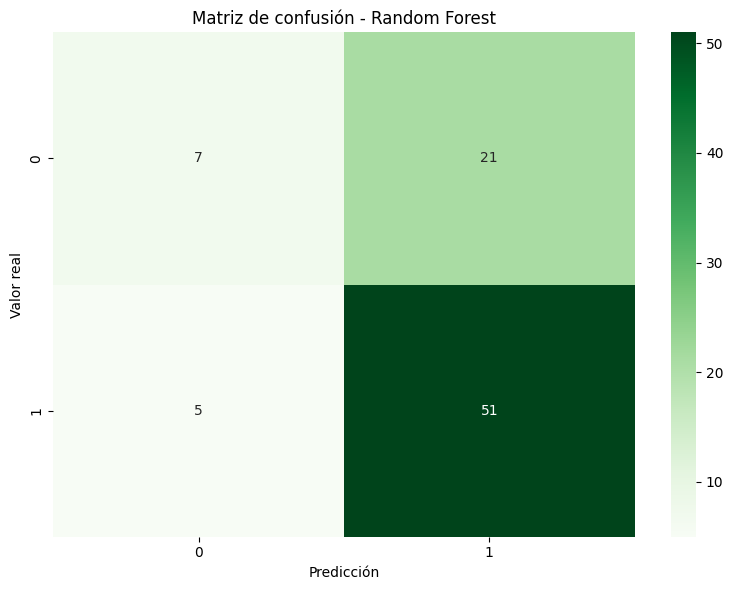

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar modelo Random Forest con 100 árboles
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

# Métricas de evaluación
print('Accuracy Random Forest:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

## 8. Importancia de variables (Random Forest)

             Variable  Importancia
9   motivo_especifico     0.175374
0                 mes     0.164142
3           afec_edad     0.159353
6          ent_nombre     0.157362
1           pqr_canal     0.098253
5  afec_regafiliacion     0.059388
7         macromotivo     0.051382
2         afec_genero     0.051027
8      motivo_general     0.050911
4          afec_edadr     0.032808


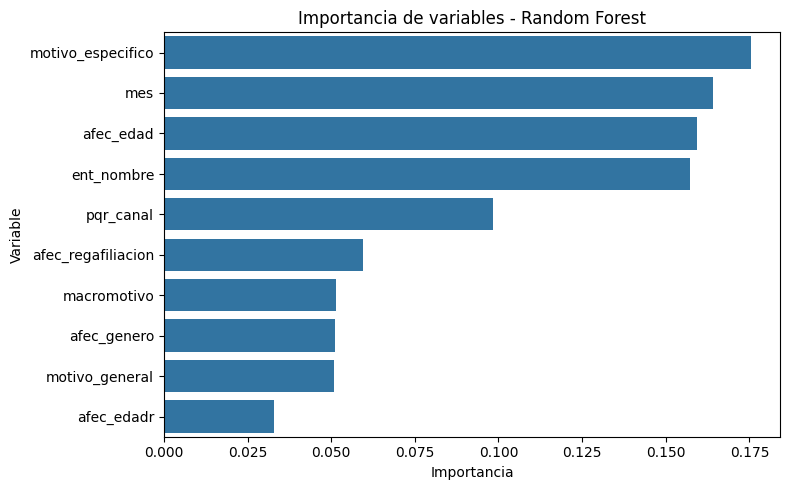

In [35]:
# Identificar qué variables tienen mayor peso en la predicción del modelo
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(df_importancia)

# Visualización de importancia de variables
plt.figure(figsize=(8, 5))
sns.barplot(data=df_importancia, x='Importancia', y='Variable')
plt.title('Importancia de variables - Random Forest')
plt.tight_layout()
plt.show()